# Modelos de Series de Tiempo Univariadas: Variación Porcentual en el Precio de la acción CEMEXCP0 con un modelo LSTM

**Objetivo:** Hacer predicciones de los valores de una serie de tiempo, UN PASO HACIA ADELANTE, empleando un modelo de redes neuronales de memoria a corto y largo plazo (LSTM).

In [ ]:
# Cargar nuestras librerias
import numpy as np
import pandas as pd

# Para series de tiempo económicas y financieras
import datetime as dt    # Para procesar fechas
import yfinance as yf    # Para descargar series de tiempo
                         # financieras a través del portal de yahoo.

# Preprocesamiento y métricas
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Graficas
import matplotlib.pyplot as plt

In [ ]:
# Identificar el dispositivo de trabajo CPU/GPU
# MPS (chip de Apple en Mac) -> CUDA (Colab con GPU) -> CPU
device=('mps' if torch.backends.mps.is_available() else
        'cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

# FASE I: Preparar los datos

- Cargamos el conjunto de datos.  (descargar de Yahoo)
- Modificar la función de crear ventana para más pasos hacia adelante (horizonte)
- preprocesamos los datos, listos para entrenar la red neuronal.

In [ ]:
# Leer los datos
# Delimitamos el intervalo de observación de la serie
fecha_inicio=dt.datetime(2023,8,28)  # Año, mes y día
fecha_final=dt.datetime(2026,9,4)
datos=yf.download('CEMEXCPO.MX', start=fecha_inicio, end=fecha_final, progress=False, auto_adjust=True)
# Versiones recientes de yfinance devuelven columnas con doble nivel (Precio, Ticker)
if isinstance(datos.columns, pd.MultiIndex):
    datos.columns=datos.columns.get_level_values(0)
datos.tail()



/tmp/ipykernel_2145/3132553675.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos=yf.download('CEMEXCPO.MX', fecha_inicio, fecha_final, interval='1d')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CEMEXCPO.MX,CEMEXCPO.MX,CEMEXCPO.MX,CEMEXCPO.MX,CEMEXCPO.MX
Date,,,,,
2026-08-28,18.580000,18.66,18.400000,18.660000,17547202
2026-08-31,18.320000,18.58,18.280001,18.500000,119352626
2026-09-01,17.830000,18.40,17.760000,18.400000,19314196
2026-09-02,18.000000,18.17,17.809999,17.809999,22323591
2026-09-03,18.450001,18.50,18.030001,18.040001,32917935


# Pronósticos para el precio _al cierre_ de la acción

In [ ]:
precio = datos["Close"]
precio

Ticker,CEMEXCPO.MX
Date,
2023-08-28,13.617801
2023-08-29,13.804750
2023-08-30,13.696516
2023-08-31,13.371816
2023-09-01,13.539084
...,...
2026-08-28,18.580000
2026-08-31,18.320000
2026-09-01,17.830000


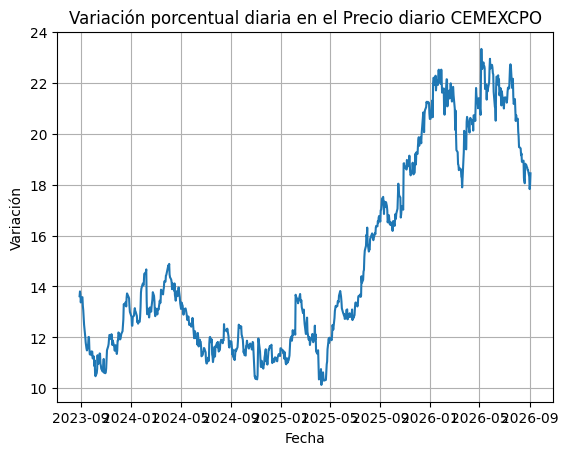

In [ ]:
#Dprecio=np.diff(np.log(precio),n=1,axis=0)   # Primeras diferencias del Logaritmo natural
plt.plot(precio)

plt.title("Variación porcentual diaria en el Precio diario CEMEXCPO")
plt.xlabel("Fecha")
plt.ylabel("Variación")
plt.grid()
plt.show()

### Construcción de la ventana de datos.
paso 1. seleccionar los conjuntos de entrenamiento-validación-prueba  
paso 2. escalamiento de los datos  
paso 3. construir las ventanas de datos   
>paso 3.1  rezago=? Dependerá de la frecuencia con la que se registran las observaciones.




In [ ]:
# Paso 1. Seleccionar los conjuntos de entrenamiento(70%)-validación(20%)-prueba(10%)

n=len(precio)  # Cantidad de observaciones
n_train=int(n*.90)  # Cantidad de datos para entrenar
n_val=int(n*0.05)     # Cantidad de datos para validación

# valores=Dprecio.reshape(-1,1)
valores=precio.values.reshape(-1,1)   # Serie en niveles como arreglo 2D (sklearn >= 1.9)
train=valores[:n_train]   # Datos de entrenamiento
val=valores[n_train:(n_train+n_val)]  # Datos de validación
test=valores[(n_train+n_val):]  # Datos de prueba

In [ ]:
# Paso 2. Escalamiento/ Normalización de los datos
scale=StandardScaler()                   # Escala que aplicaremos
train_std=scale.fit_transform(train)     # Aprendemos y aplicamos la escala en el conjunto de entrenamiento
val_std=scale.transform(val)             # Aplicamos el escalamiento aprendido a los conjuntos
test_std=scale.transform(test)           # de validación y prueba

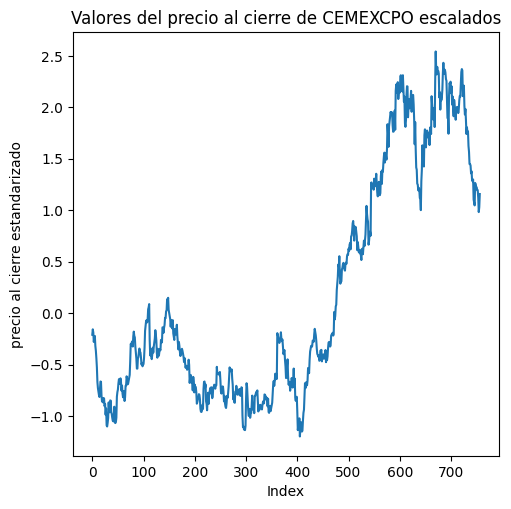

In [ ]:
# Cómo se ve la serie despues de escalar los datos
plt.figure(figsize=(5.5, 5.5))
plt.title('Valores del precio al cierre de CEMEXCPO escalados')
plt.xlabel('Index')
plt.ylabel('precio al cierre estandarizado')
plt.plot(np.concatenate((train_std,val_std,test_std)))

In [ ]:
# Paso 3. Constuir la ventanas temporales
# Construimos una función que nos va a construir las ventanas de una serie
# de tiempo utilizando k rezagos y h pasos hacia adelante

def crear_ventana(serie,k,h):
  X=[]   # Aquí van los atributos (predictores)
  y=[]   # Aquí va el target (objetivo)
  for t in range(len(serie)-k-h+1):
    X.append(serie[t:t+k])
    y.append(serie[t+k:t+k+h])
  return np.array(X), np.array(y)

In [ ]:
rezagos=7     # Información de 7 días previos
horizonte=1   # Un paso hacia adelante.
X_train,y_train=crear_ventana(train_std,rezagos,horizonte)
X_val,y_val=crear_ventana(val_std,rezagos,horizonte)
X_test,y_test=crear_ventana(test_std,rezagos,horizonte)

In [ ]:
# Convertir los datos de entrenamiento, validación y prueba a Tensor
# y los subimos al device
X_train=torch.tensor(X_train, dtype=torch.float32, device=device)
X_val=torch.tensor(X_val, dtype=torch.float32, device=device)
X_test=torch.tensor(X_test, dtype=torch.float32, device=device)
y_train=torch.tensor(y_train, dtype=torch.float32, device=device)
y_val=torch.tensor(y_val, dtype=torch.float32, device=device)
y_test=torch.tensor(y_test, dtype=torch.float32, device=device)

In [ ]:
y_train=y_train.squeeze(-1)
y_val=y_val.squeeze(-1)
y_test=y_test.squeeze(-1)


# FASE II. Desarrollar la Arquitectura del Modelo
Abarca desde definir la arquitectura del modelo hasta instanciar el modelo y montarlo en el dispositivo adecuado

In [ ]:
# ¿Cuántos inputs y cuántos outputs tenemos?
print(f'Inputs: {X_train.shape[1]} atributos')  # Ojo debe estar relacionado con el número de rezagos
print(f'Outputs: {y_train.shape[1]}-paso(s) hacia adelante')

Inputs: 7 atributos
Outputs: 1-paso(s) hacia adelante


In [ ]:
# Un modelo de Red Neuronal LSTM
class ModeloLSTM(nn.Module):
  def __init__(self, oculto=32):  # Es una serie univariada
    super().__init__()
    self.lstm=nn.LSTM(1,oculto,batch_first=True)
    self.salida=nn.Linear(oculto,1)

  def forward(self, x):
    secuencia, _ = self.lstm(x)
    # Extraemos únicamente la salida de la RNN
    ultima =secuencia[:,-1,:]
    return self.salida(ultima)

#Instanciamos el modelo y lo colocamos en el device
torch.manual_seed(42)
modelo=ModeloLSTM()
modelo.to(device)


ModeloLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (salida): Linear(in_features=32, out_features=1, bias=True)
)

# FASE III. Compilar el modelo
Definir al optimizador y la función de pérdida

In [ ]:
loss_fn=nn.MSELoss()
optimizer= optim.Adam(modelo.parameters(), lr=0.001)

# FASE IV: Entrenar el modelo

In [ ]:
# Número de épocas
n_epochs=1000

# Trazabilidad de la pérdida y la métrica
loss_train=[]
loss_val=[]
metric_train=[]
metric_val=[]

for epochs in range(n_epochs):
  # Poner al modelo en modo train
  modelo.train()
  # Hacemos las predicciones
  y_pred_train=modelo(X_train)
  # Calculamos la pérdida
  loss=loss_fn(y_pred_train,y_train)
  loss_train.append(loss.detach().cpu().numpy())
  # Calculamos los gradientes de cada parámetros
  loss.backward()
  # Actualizo los valores de los parámetros
  optimizer.step()
  # Evito que los gradientes se acumulen
  optimizer.zero_grad()
  # Métrica de desempeño en el train: MAE ( MSE o r2_score)
  metric=mean_absolute_error(y_pred_train.detach().cpu().numpy(),y_train.detach().cpu().numpy())
  metric_train.append(metric)

  # En el de validación
  with torch.no_grad():
    # Para la pérdida
    y_pred_val=modelo(X_val)
    loss=loss_fn(y_pred_val,y_val)
    loss_val.append(loss.detach().cpu().numpy())
    # Para la métrica
    metric=mean_absolute_error(y_pred_val.detach().cpu().numpy(),y_val.detach().cpu().numpy())
    metric_val.append(metric)


# FASE V: Mejorar el Desempeño del Modelo

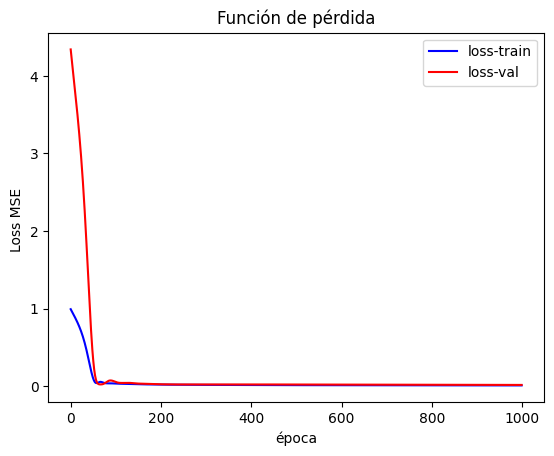

In [ ]:
# Monitoreo de la evolución del modelo
plt.plot(range(n_epochs), loss_train, label='loss-train', color='Blue')
plt.plot(range(n_epochs), loss_val, label='loss-val', color='Red')
plt.ylabel('Loss MSE ')
plt.xlabel('época')
plt.title('Función de pérdida')
plt.legend()

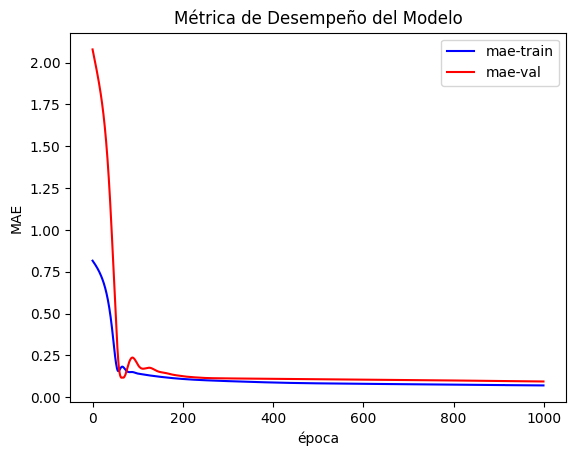

In [ ]:
plt.plot(range(n_epochs), metric_train, label='mae-train', color='Blue')
plt.plot(range(n_epochs), metric_val, label='mae-val', color='Red')
plt.ylabel('MAE')
plt.xlabel('época')
plt.title('Métrica de Desempeño del Modelo')
plt.legend()

# Calificar el desempeño del mejor modelo entrenado.
Esta evaluación la hacemos en el conjunto de prueba

In [ ]:
# Pérdida del modelo en el X_test
with torch.no_grad():
  y_pred=modelo(X_test)
  loss=loss_fn(y_pred,y_test)
print('Loss:', loss)


Loss: tensor(0.0140, device='cuda:0')


In [ ]:
# Métrica del modelo en el X_test
mean_absolute_error(y_pred.detach().cpu().numpy(),y_test.detach().cpu().numpy())

0.10273207724094391

In [ ]:
# Las predicciones están escaladas.... necesiamos pasarlas a la escala original
# Revertir el escalamiento
y_pred = scale.inverse_transform(y_pred.detach().cpu().numpy()).reshape(1,-1)   # Ya están en la escala original


# NOTA.

¿Cómo decidimos el número de rezagos?  
- A través de la métricos del modelo en el conjunto de prueba. Es decir, ponemos a competir varios valores de rezago, por ejemplo rezagos=1,2,4,5,6,7 y comparamos los valores obtenidos en la métrica del modelo obtenida en el conjunto de prueba. La métrica menor (con la que menos se equivoca el modelo) es un indicativo del valor adecuado para la variable rezago.


# Predicción de los días siguientes!!!

In [ ]:
ultimo_periodo=scale.transform(valores[-rezagos:]).reshape(1,rezagos,1)
ultimo_periodo=torch.tensor(ultimo_periodo,dtype=torch.float32, device=device)

In [ ]:
with torch.no_grad():
  y_pred=modelo(ultimo_periodo)
print("Pronóstico del modelo (escalada):", y_pred)
print("Pronóstico del modelo para el dia hábil siguiente(escala original):",\
      scale.inverse_transform(y_pred.detach().cpu().numpy()).reshape(1,-1))

Pronóstico del modelo (escalada): tensor([[1.1044]], device='cuda:0')
Pronóstico del modelo para el dia hábil siguiente(escala original): [[18.259937]]


In [ ]:
precio[-3:]  # Últimos tres valores de la serie...

Ticker,CEMEXCPO.MX
Date,
2026-09-01,17.830000
2026-09-02,18.000000
2026-09-03,18.450001


In [ ]:
# Predicciones en el conjunto de entrenamiento
with torch.no_grad():
  y_pred_train=modelo(X_train) # <- estos valores están escalados

# Desescalados
y_pred_train= scale.inverse_transform(y_pred_train.detach().cpu().numpy())

# Predicciones en el conjunto de prueba
with torch.no_grad():
  y_pred=modelo(X_test)  # <- estos valores están escalados
# Desescalados



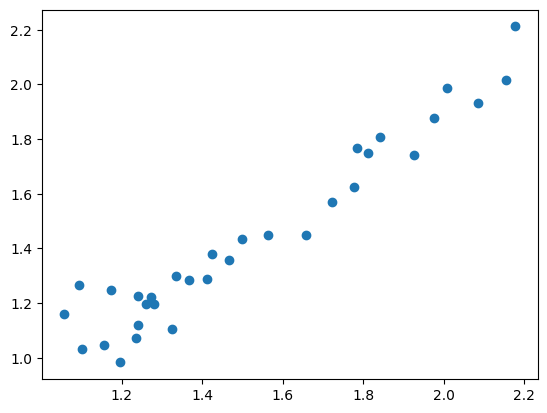

In [ ]:
plt.scatter(y_pred.detach().cpu().numpy(),y_test.detach().cpu().numpy())

# Gráficas del Modelo

In [ ]:
# Conjunto de prueba
y_pred= scale.inverse_transform(y_pred.detach().cpu().numpy())
valores[(n_train+n_val):]
y_test=np.full(n_train+n_val+1,np.nan)
y_test=np.concatenate((y_test,y_pred.squeeze()))


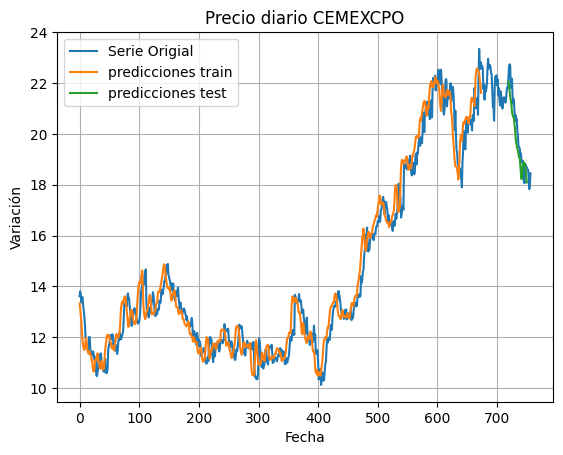

In [ ]:
plt.plot(precio.values, label='Serie Origial')
plt.plot(y_pred_train, label="predicciones train")

plt.plot(y_test, label='predicciones test')

plt.title("Precio diario CEMEXCPO")
plt.xlabel("Fecha")
plt.ylabel("Variación")
plt.grid()
plt.legend()
plt.show()

# Tarea.

* Utilizar la serie en niveles, aunque como ya vimos no es estacionaria.

1. Emplear los modelos RNN y LSTM para predicción en un paso hacia adelante para dos series financieras. GOOGL y NVDA

2. Emplear los modelos RNN y LSTM para predicción en cinco pasos hacia adelante para dos series financieras. GOOGL y NVDA


**NOTA:** TODAS las tareas se entregan en formato HTML, para ello, debes correr en COLAB todo el script (tablas y gráficos visibles). Después descargas el notebook de colab en formato *.ipynb (archivos->descargar). Posteriormente en ANACONDA de tu PC, abrir el archivo que descargaste y lo guardas como HTML (File-> Save Export As-> HTML)


## Resolución de la Tarea

- Se usan las series **en niveles** (aunque, como vimos, no son estacionarias) de **GOOGL** y **NVDA**.
- Se entrenan los modelos **RNN** y **LSTM** para predicción a **1 paso** y a **5 pasos** hacia adelante (8 experimentos en total).
- Se conserva el pipeline de la clase: ventana de 7 rezagos, partición 90/5/5, StandardScaler, MSE + Adam, 1000 épocas y semilla 42.

In [ ]:
# Utilidades para la tarea: descarga (con caché) y modelos RNN/LSTM parametrizados por h
_cache = {}
def descargar(ticker):
    if ticker not in _cache:
        datos = yf.download(ticker, start=fecha_inicio, progress=False, auto_adjust=True)
        if isinstance(datos.columns, pd.MultiIndex):
            datos.columns = datos.columns.get_level_values(0)
        _cache[ticker] = datos
    return _cache[ticker]

class ModeloLSTM_h(nn.Module):
    def __init__(self, oculto=32, h=1):
        super().__init__()
        self.lstm = nn.LSTM(1, oculto, batch_first=True)
        self.salida = nn.Linear(oculto, h)
    def forward(self, x):
        secuencia, _ = self.lstm(x)
        return self.salida(secuencia[:, -1, :])

class ModeloRNN_h(nn.Module):
    def __init__(self, oculto=32, h=1):
        super().__init__()
        self.rnn = nn.RNN(1, oculto, batch_first=True)
        self.salida = nn.Linear(oculto, h)
    def forward(self, x):
        secuencia, _ = self.rnn(x)
        return self.salida(secuencia[:, -1, :])

def experimento(ticker, tipo, h, n_epochs=1000):
    # Serie en NIVELES (no estacionaria)
    precio = descargar(ticker)['Close']
    valores = precio.values.reshape(-1, 1)

    n = len(valores)
    n_train, n_val = int(n * .90), int(n * .05)
    train = valores[:n_train]
    val = valores[n_train:n_train + n_val]
    test = valores[n_train + n_val:]

    scale = StandardScaler()
    train_std = scale.fit_transform(train)
    val_std = scale.transform(val)
    test_std = scale.transform(test)

    X_train, y_train = crear_ventana(train_std, rezagos, h)
    X_val, y_val = crear_ventana(val_std, rezagos, h)
    X_test, y_test = crear_ventana(test_std, rezagos, h)
    y_train = y_train.squeeze(-1)   # (n, h)
    y_val = y_val.squeeze(-1)
    y_test = y_test.squeeze(-1)

    X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
    X_val = torch.tensor(X_val, dtype=torch.float32, device=device)
    X_test = torch.tensor(X_test, dtype=torch.float32, device=device)
    y_train = torch.tensor(y_train, dtype=torch.float32, device=device)
    y_val = torch.tensor(y_val, dtype=torch.float32, device=device)
    y_test = torch.tensor(y_test, dtype=torch.float32, device=device)

    torch.manual_seed(42)
    modelo = (ModeloLSTM_h(h=h) if tipo == 'LSTM' else ModeloRNN_h(h=h)).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)

    loss_train, loss_val, metric_train, metric_val = [], [], [], []
    for epochs in range(n_epochs):
        modelo.train()
        y_pred_train = modelo(X_train)
        loss = loss_fn(y_pred_train, y_train)
        loss_train.append(loss.detach().cpu().numpy())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        metric = mean_absolute_error(y_pred_train.detach().cpu().numpy(), y_train.detach().cpu().numpy())
        metric_train.append(metric)
        with torch.no_grad():
            y_pred_val = modelo(X_val)
            loss = loss_fn(y_pred_val, y_val)
            loss_val.append(loss.detach().cpu().numpy())
            metric = mean_absolute_error(y_pred_val.detach().cpu().numpy(), y_val.detach().cpu().numpy())
            metric_val.append(metric)

    with torch.no_grad():
        y_pred = modelo(X_test)
        loss_test = loss_fn(y_pred, y_test).item()
    y_pred_np = scale.inverse_transform(y_pred.detach().cpu().numpy().reshape(-1, 1)).reshape(y_test.shape[0], h)
    y_test_np = scale.inverse_transform(y_test.detach().cpu().numpy().reshape(-1, 1)).reshape(y_test.shape[0], h)

    return {
        'ticker': ticker, 'modelo': tipo, 'h': h,
        'loss_train': loss_train, 'loss_val': loss_val,
        'metric_train': metric_train, 'metric_val': metric_val,
        'loss_test': loss_test,
        'mae': mean_absolute_error(y_test_np.ravel(), y_pred_np.ravel()),
        'mse': mean_squared_error(y_test_np.ravel(), y_pred_np.ravel()),
        'r2': r2_score(y_test_np.ravel(), y_pred_np.ravel()),
        'y_test': y_test_np, 'y_pred': y_pred_np,
    }

In [ ]:
# Los 8 experimentos: GOOGL y NVDA, con RNN y LSTM, a 1 y 5 pasos hacia adelante
resultados = {}
for ticker in ['GOOGL', 'NVDA']:
    for tipo in ['RNN', 'LSTM']:
        for h in [1, 5]:
            r = experimento(ticker, tipo, h)
            resultados[(ticker, tipo, h)] = r
            print(f"{ticker} {tipo} h={h}: MAE={r['mae']:.4f}  MSE={r['mse']:.4f}  R2={r['r2']:.4f}")

In [ ]:
# Comparación de las métricas de desempeño en el conjunto de prueba
tabla = pd.DataFrame([
    {'Serie': k[0], 'Modelo': k[1], 'Pasos (h)': k[2],
     'MSE': v['mse'], 'MAE': v['mae'], 'R2': v['r2']}
    for k, v in resultados.items()
])
tabla.round(3)

In [ ]:
# Monitoreo de la evolución del entrenamiento (pérdida train vs validación)
for ticker in ['GOOGL', 'NVDA']:
    fig, ejes = plt.subplots(2, 2, figsize=(12, 8))
    for (tipo, h), ax in zip([('RNN', 1), ('LSTM', 1), ('RNN', 5), ('LSTM', 5)], ejes.ravel()):
        r = resultados[(ticker, tipo, h)]
        ax.plot(range(len(r['loss_train'])), r['loss_train'], label='loss-train', color='Blue')
        ax.plot(range(len(r['loss_val'])), r['loss_val'], label='loss-val', color='Red')
        ax.set_title(f"{ticker} {tipo} h={h}")
        ax.set_xlabel('época'); ax.set_ylabel('Loss (MSE)')
        ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Predicción vs valor real en el conjunto de prueba (para h=5 se grafica el paso más lejano, t+5)
for ticker in ['GOOGL', 'NVDA']:
    fig, ejes = plt.subplots(2, 2, figsize=(12, 8))
    for (tipo, h), ax in zip([('RNN', 1), ('LSTM', 1), ('RNN', 5), ('LSTM', 5)], ejes.ravel()):
        r = resultados[(ticker, tipo, h)]
        ax.plot(r['y_test'][:, -1], label='real', color='Blue')
        ax.plot(r['y_pred'][:, -1], label='predicción', color='Red')
        ax.set_title(f"{ticker} {tipo} h={h}")
        ax.legend()
    plt.tight_layout()
    plt.show()

### Resultados de la Tarea

Métricas en el conjunto de prueba (serie en niveles):

| Serie | Modelo | Pasos (h) | MAE | R² |
|-------|--------|-----------|-----|-----|
| GOOGL | RNN  | 1 | 4.17 | -0.17 |
| GOOGL | LSTM | 1 | 3.86 | -0.01 |
| GOOGL | RNN  | 5 | 5.33 | -0.43 |
| GOOGL | LSTM | 5 | 5.04 | -0.37 |
| NVDA  | RNN  | 1 | 4.20 | 0.29 |
| NVDA  | LSTM | 1 | 4.75 | 0.18 |
| NVDA  | RNN  | 5 | 7.61 | -0.86 |
| NVDA  | LSTM | 5 | 7.63 | -0.87 |

**Observaciones:**

- Predecir a **1 paso (h=1)** es claramente mejor que a **5 pasos (h=5)** en las 4 combinaciones: el error crece con el horizonte.
- Con la serie **en niveles** (no estacionaria) el R² queda cerca de 0 o es negativo: los modelos apenas superan la estrategia de repetir el último valor. Esto confirma lo visto en clase: conviene trabajar con la serie estacionaria (variación porcentual).
- **GOOGL**: el LSTM supera ligeramente a la RNN en ambos horizontes (MAE 3.86 vs 4.17 en h=1).
- **NVDA**: RNN y LSTM rinden parecido en h=1 (MAE 4.20 vs 4.75, gana RNN); en h=5 ambos empeoran por igual.